# A complete SVM implemententation with hyperparameter tuning on iris datatset

In [13]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [14]:
#load the dataset
iris=load_iris() # split dependent
X=iris.data
y=iris.target
print("Feature shape of X:", X.shape)
print("Target shape of y:", y.shape)


Feature shape of X: (150, 4)
Target shape of y: (150,)


In [15]:
#Visulization (use only two features)
X=X[:,:2]

In [16]:
#split the dataset into training and testing sets(70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
#Feature scaling(for SVM)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [18]:
#Train basic SVM model 
svm_model=SVC(kernel='rbf')
svm_model.fit(X_train,y_train)
y_pred=svm_model.predict(X_test)

print(f"Accuracy(Before Tuning):",accuracy_score(y_test,y_pred))

Accuracy(Before Tuning): 0.8333333333333334


In [19]:
#Hyperparameter tuning using GridSearchCV
#c=Regularization
#gamma=kernel cofficient
#kernel=linear, rbf, poly
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,100],'gamma':[1,1.0,0.01,0.001],'kernel':['rbf','kernel','poly']}
grid=GridSearchCV(SVC(),param_grid,cv=5,verbose=2,n_jobs=-1)
grid.fit(X_train,y_train)
print("Best Parameter:",grid.best_params_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameter: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


In [20]:
#Evalute the best model 
best_model=grid.best_estimator_
y_pred=best_model.predict(X_test)
print(f"Final Accuracy:", accuracy_score(y_test,y_pred))
print(f"Confusion Matrix:",confusion_matrix(y_test,y_pred))
print(f"Classification Report:",classification_report(y_test,y_pred))

Final Accuracy: 0.8
Confusion Matrix: [[10  0  0]
 [ 0  7  2]
 [ 0  4  7]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.64      0.78      0.70         9
           2       0.78      0.64      0.70        11

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.81      0.80      0.80        30



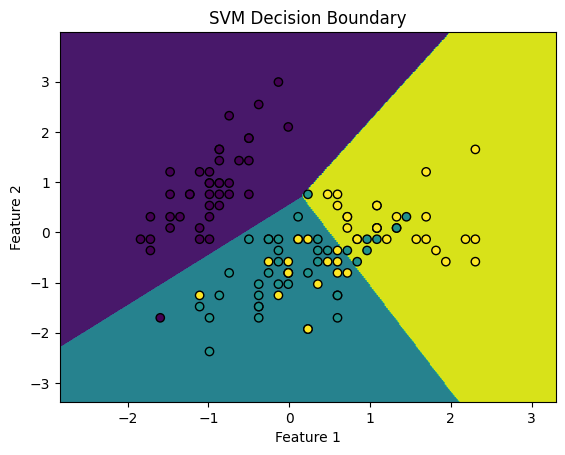

In [21]:
# Visualization
def plot_decision_boundary(model,x,y):
    x_min,x_max=x[:,0].min()-1,x[:,0].max()+1
    y_min,y_max=x[:,1].min()-1,x[:,1].max()+1
    xx, yy = np.meshgrid(
         np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy,Z)
    plt.scatter(x[:, 0], x[:, 1], c=y,edgecolors='k')
    plt.title("SVM Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
plot_decision_boundary(best_model,X_train,y_train)